# **Project Title : Customer Churn Prediction using Supervised Machine Learning** 



**Objective:**

The objective of this task is to understand the end-to-end workflow of a machine learning project. Students should perform basic Exploratory Data Analysis (EDA), apply data preprocessing techniques, build a supervised machine learning model, and create a simple Streamlit application for prediction.


**Churn**:  Churn means a customer stops using a company’s product or service.

- Yes → Customer left the company

- No → Customer is still with the company


In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import necessary libraries for encoding
from sklearn.preprocessing import LabelEncoder
#Feature Scaling
from sklearn.discriminant_analysis import StandardScaler

# importing necessary models and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

1. Exploratory Data Analysis (EDA):

In [2]:
# loading dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# displaying the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# checking Dataset shape
df.shape

(7043, 21)

In [5]:
# checking dataype of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Identifying missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)
df.shape # no duplicate values present

(7043, 21)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Converting the target column (Churn) into numerical format
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [10]:
# Identify categorical and numerical columns
cat_cols = []
num_cols = []

for col in df.columns:
    
   
    if df[col].dtype == 'object':
        cat_cols.append(col)    
    else:
        num_cols.append(col)

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn']


In [11]:
# Exploring customerID column
# Displaying the unique values in customerID column
df['customerID'].unique()
len(df['customerID'].unique())
df.drop("customerID",axis = 1,inplace = True)

In [12]:
# Exploring gender column
# Displaying the unique values in gender column
df['gender'].unique()

# Exploring the count of each gender
df['gender'].value_counts()

# df['gender']=df['gender'].str.strip()


gender
Male      3555
Female    3488
Name: count, dtype: int64

In [13]:
# Exploring SeniorCitizen column
# Displaying the unique values in SeniorCitizen column
df['SeniorCitizen'].unique()

# Exploring the count of each category
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [14]:
# Exploring Partner column
# Displaying the unique values in Partner column
df['Partner'].unique()

# Exploring the count of each category
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [15]:
# Exploring Dependents column
# Displaying the unique values in Dependents column
df['Dependents'].unique()

# Exploring the count of each category
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [16]:
# Exploring tenure column
# Displaying the unique values in tenure column
df['tenure'].unique()
len(df['tenure'].unique())

# Exploring the count of each tenure value
df['tenure'].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

In [17]:
# Exploring PhoneService column
# Displaying the unique values in PhoneService column
df['PhoneService'].unique()

# Exploring the count of each category
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [18]:
# Exploring MultipleLines column
# Displaying the unique values in MultipleLines column
df['MultipleLines'].unique()

# Exploring the count of each category
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [19]:
# Exploring InternetService column
# Displaying the unique values in InternetService column
df['InternetService'].unique()

# Exploring the count of each internet service type
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [20]:
# Exploring OnlineSecurity column
# Displaying the unique values in OnlineSecurity column
df['OnlineSecurity'].unique()

# Displaying the count of each category
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [21]:
# Exploring OnlineBackup column
# Displaying the unique values in OnlineBackup column
df['OnlineBackup'].unique()

# Displaying the count of each category
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [22]:
# Exploring DeviceProtection column
# Displaying the unique values in DeviceProtection column
df['DeviceProtection'].unique()

# Displaying the count of each category
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [23]:
# Exploring TechSupport column
# Displaying the unique values in TechSupport column
df['TechSupport'].unique()

# Displaying the count of each category
df['TechSupport'].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [24]:
# Exploring StreamingTV column
# Displaying the unique values in StreamingTV column
df['StreamingTV'].unique()

# Displaying the count of each category
df['StreamingTV'].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [25]:
# Exploring StreamingMovies column
# Displaying the unique values in StreamingMovies column
df['StreamingMovies'].unique()

# Displaying the count of each category
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [26]:
# Exploring Contract column
# Displaying the unique values in Contract column
df['Contract'].unique()

# Displaying the count of each contract type
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [27]:
# Exploring PaperlessBilling column
# Displaying the unique values in PaperlessBilling column
df['PaperlessBilling'].unique()

# Displaying the count of each category
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [28]:
# Exploring PaymentMethod column
# Displaying the unique values in PaymentMethod column
df['PaymentMethod'].unique()

# Displaying the count of each payment method
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [29]:
# Exploring MonthlyCharges column
# Displaying the unique values in MonthlyCharges column
df['MonthlyCharges'].unique()

# Displaying the count of each monthly charge value
df['MonthlyCharges'].value_counts()

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
56.85      1
101.70     1
48.40      1
108.35     1
72.00      1
Name: count, Length: 1585, dtype: int64

In [30]:
# Exploring TotalCharges column
# Displaying the unique values in TotalCharges column
df['TotalCharges'].unique()

# Displaying the count of each total charge value
df['TotalCharges'].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [31]:
# Exploring Churn column
# Displaying the unique values in Churn column
df['Churn'].unique()

# Displaying the count of churn and non-churn customers
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

2. Data Preprocessing:
- Handle missing values
- Encode categorical variables
- Split the data into training and testing sets
- Apply feature scaling if required


In [32]:
df.isnull().sum() # No missing values

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [33]:
# Label Encoding
encoder = LabelEncoder()

# converting categorical columns to numerical columns
for col in df.columns:
    if df[col].dtype == object:   
        df[col] = encoder.fit_transform(df[col])

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


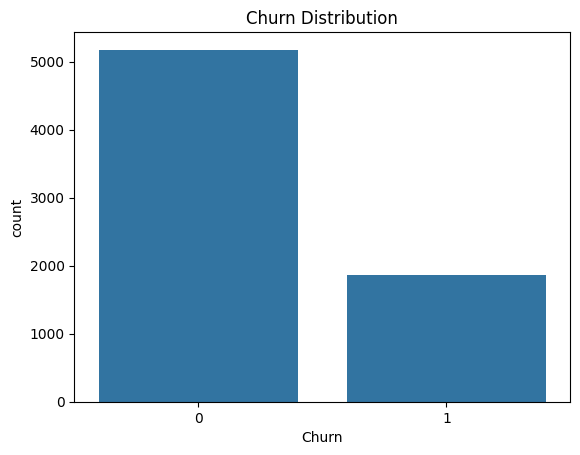

In [35]:
#Distribution of churn
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

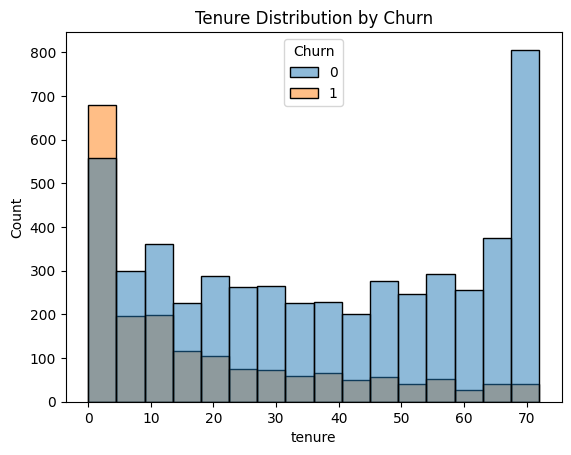

In [56]:
#Distribution of customer tenure based on churn
sns.histplot(data=df, x='tenure', hue='Churn')
plt.title('Tenure Distribution by Churn')
plt.show()

In [36]:
# Separating input features (X) and target variable (y)
X = df.drop(["Churn"],axis = 1)
y = df['Churn']

In [37]:
# Splitting the data into Traing and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)


3. Supervised Machine Learning Model:
- Use supervised algorithms (Logistic Regression , SVM, DecisionTreeClassifier)
- Use best performing model in streamlit app
- Train the model on training data
- Evaluate the model using accuracy, confusion matrix, and classification report


Logistic Regression

In [38]:
# model Training
LR = LogisticRegression(max_iter=2000)
LR.fit(Xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
# Predicting the target values for the test data
ypred = LR.predict(Xtest)
ypred

array([1, 0, 0, ..., 0, 1, 0], shape=(2113,))

In [40]:
# Calculating training and testing efficiency
print("Training Eff : ",LR.score(Xtrain,ytrain))
print("Testing Eff : ",LR.score(Xtest,ytest))

Training Eff :  0.8038539553752535
Testing Eff :  0.8078561287269286


In [41]:
# Generating the confusion matrix 
confusion_matrix(ytest, ypred)

array([[1395,  144],
       [ 262,  312]])

In [42]:
# Displaying the classification report 
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1539
           1       0.68      0.54      0.61       574

    accuracy                           0.81      2113
   macro avg       0.76      0.72      0.74      2113
weighted avg       0.80      0.81      0.80      2113



SVM

In [43]:
# model Training
SVC = SVC()
SVC.fit(Xtrain,ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [44]:
# Predicting the target values for the test data
ypred = SVC.predict(Xtest)
ypred

array([0, 0, 0, ..., 0, 0, 0], shape=(2113,))

In [45]:
# Calculating training and testing efficiency
print("Training Eff : ",SVC.score(Xtrain,ytrain))
print("Testing Eff : ",SVC.score(Xtest,ytest))

Training Eff :  0.7373225152129818
Testing Eff :  0.7283483199242783


In [46]:
# Generating the confusion matrix 
confusion_matrix(ytest, ypred)

array([[1539,    0],
       [ 574,    0]])

In [47]:
# Displaying the classification report 
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1539
           1       0.00      0.00      0.00       574

    accuracy                           0.73      2113
   macro avg       0.36      0.50      0.42      2113
weighted avg       0.53      0.73      0.61      2113



c:\Users\padmasri\Desktop\Customer Churn Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\padmasri\Desktop\Customer Churn Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\padmasri\Desktop\Customer Churn Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

DecisionTreeClassifier

In [48]:
# model Training
DC = DecisionTreeClassifier()
DC.fit(Xtrain,ytrain)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [49]:
# Predicting the target values for the test data
ypred = DC.predict(Xtest)
ypred

array([1, 0, 0, ..., 0, 0, 0], shape=(2113,))

In [50]:
# Calculating training and testing efficiency
print("Training Eff : ",DC.score(Xtrain,ytrain))
print("Testing Eff : ",DC.score(Xtest,ytest))

Training Eff :  0.9983772819472616
Testing Eff :  0.7221959299574066


In [51]:
# Generating the confusion matrix 
confusion_matrix(ytest, ypred)

array([[1247,  292],
       [ 295,  279]])

In [52]:
# Displaying the classification report 
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1539
           1       0.49      0.49      0.49       574

    accuracy                           0.72      2113
   macro avg       0.65      0.65      0.65      2113
weighted avg       0.72      0.72      0.72      2113



**Logistic Regression**: Achieved balanced training and testing accuracy, indicating good **generalization** and stable performance.

**Decision Tree**: It is **overfitting** as it showed very high training accuracy but lower testing accuracy.

**Support Vector Machine (SVM)**: Performed reasonably well but achieved l**ower accuracy compared to Logistic Regression**.

# Final Statement: 
**Logistic Regression** is the best model for this dataset because it provides the highest testing accuracy with better generalization compared to Decision Tree and SVM.

In [53]:

# Serialization using pickle
import pickle
with open("model.pkl","wb") as file:
    pickle.dump(LR,file)

In [54]:

# #Encoder serialization using pickle
with open("encoder.pkl","wb") as file1:
    pickle.dump(encoder, file1)

In [55]:
#save the cleaned data
df.to_csv("cleaned_data.csv")